In [2]:
from sklearn.datasets import fetch_california_housing

In [3]:
df_housing = fetch_california_housing(as_frame=True)

In [4]:
df_housing

{'data':        MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
 0      8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
 1      8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
 2      7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
 3      5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
 4      3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
 ...       ...       ...       ...        ...         ...       ...       ...   
 20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
 20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
 20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
 20638  1.8672      18.0  5.329513   1.171920       741.0  2.123209     39.43   
 20639  2.3886      16.0  5.254717   1.162264      1387.0  2.616981     39.37   
 
        Longitude 

In [5]:
df_housing = df_housing.frame

In [6]:
df_housing


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [7]:
import pandas as pd
import numpy as np

In [8]:
from sklearn.preprocessing import LabelEncoder,StandardScaler

In [9]:
from sklearn.linear_model import LinearRegression,Ridge,Lasso,ElasticNet

In [10]:
from sklearn.tree import DecisionTreeRegressor

In [11]:
import statsmodels.formula.api as smf

In [12]:
from sklearn.metrics import mean_squared_error,r2_score
from math import sqrt
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
from matplotlib.axes._axes import _log as matplotlib_axes_logger
matplotlib_axes_logger.setLevel('ERROR')

In [13]:
import math

In [14]:
df_housing.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

In [15]:
df_housing

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [16]:
df_housing.MedHouseVal

0        4.526
1        3.585
2        3.521
3        3.413
4        3.422
         ...  
20635    0.781
20636    0.771
20637    0.923
20638    0.847
20639    0.894
Name: MedHouseVal, Length: 20640, dtype: float64

In [17]:
names = df_housing.columns
scaler = StandardScaler()

In [18]:
scaled_df =  scaler.fit_transform(df_housing)

In [19]:
scaled_df

array([[ 2.34476576,  0.98214266,  0.62855945, ...,  1.05254828,
        -1.32783522,  2.12963148],
       [ 2.33223796, -0.60701891,  0.32704136, ...,  1.04318455,
        -1.32284391,  1.31415614],
       [ 1.7826994 ,  1.85618152,  1.15562047, ...,  1.03850269,
        -1.33282653,  1.25869341],
       ...,
       [-1.14259331, -0.92485123, -0.09031802, ...,  1.77823747,
        -0.8237132 , -0.99274649],
       [-1.05458292, -0.84539315, -0.04021111, ...,  1.77823747,
        -0.87362627, -1.05860847],
       [-0.78012947, -1.00430931, -0.07044252, ...,  1.75014627,
        -0.83369581, -1.01787803]], shape=(20640, 9))

In [20]:
scaled_df = pd.DataFrame(scaled_df,columns = names)

In [21]:
scaled_df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,2.344766,0.982143,0.628559,-0.153758,-0.974429,-0.049597,1.052548,-1.327835,2.129631
1,2.332238,-0.607019,0.327041,-0.263336,0.861439,-0.092512,1.043185,-1.322844,1.314156
2,1.782699,1.856182,1.155620,-0.049016,-0.820777,-0.025843,1.038503,-1.332827,1.258693
3,0.932968,1.856182,0.156966,-0.049833,-0.766028,-0.050329,1.038503,-1.337818,1.165100
4,-0.012881,1.856182,0.344711,-0.032906,-0.759847,-0.085616,1.038503,-1.337818,1.172900
...,...,...,...,...,...,...,...,...,...
20635,-1.216128,-0.289187,-0.155023,0.077354,-0.512592,-0.049110,1.801647,-0.758826,-1.115804
20636,-0.691593,-0.845393,0.276881,0.462365,-0.944405,0.005021,1.806329,-0.818722,-1.124470
20637,-1.142593,-0.924851,-0.090318,0.049414,-0.369537,-0.071735,1.778237,-0.823713,-0.992746
20638,-1.054583,-0.845393,-0.040211,0.158778,-0.604429,-0.091225,1.778237,-0.873626,-1.058608


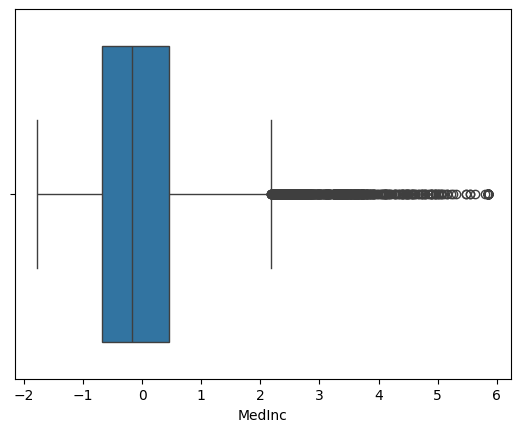

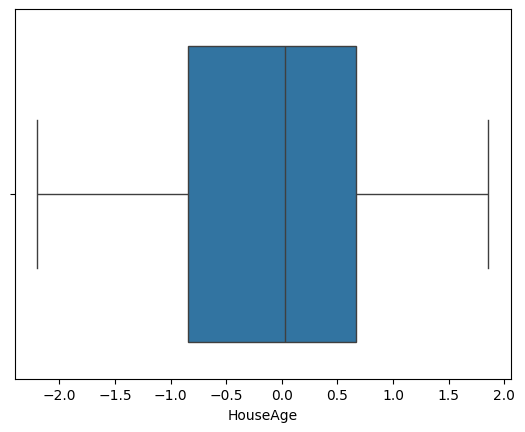

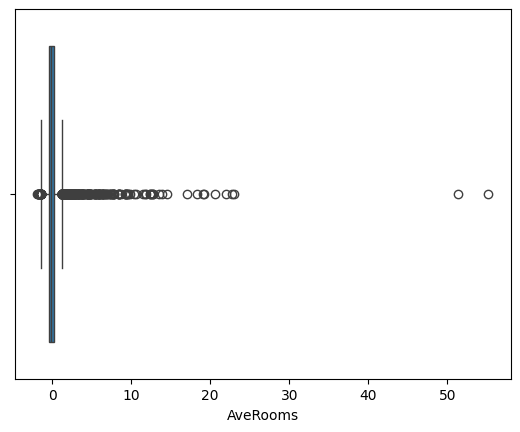

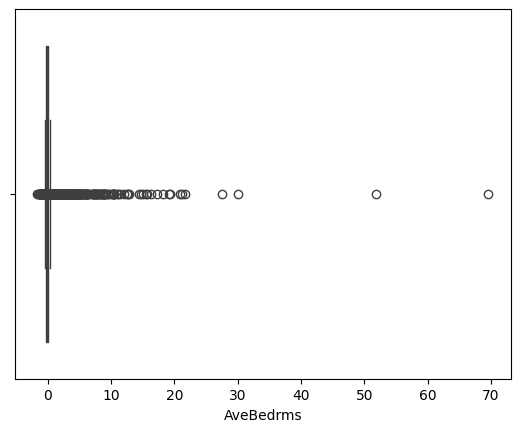

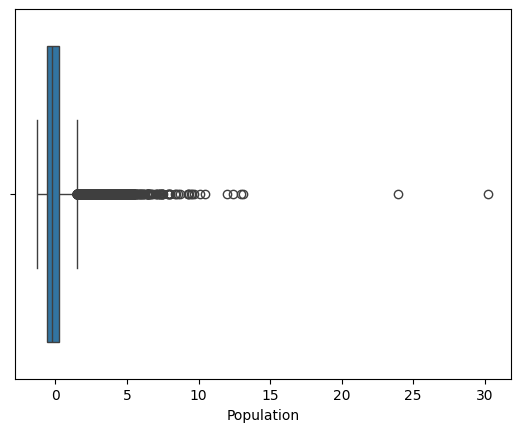

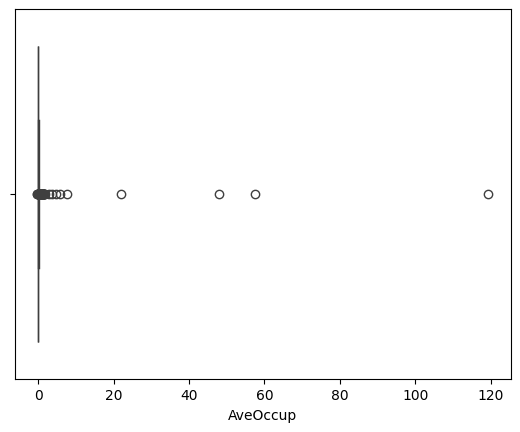

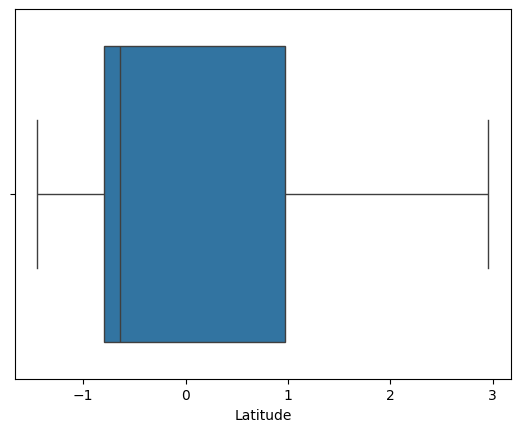

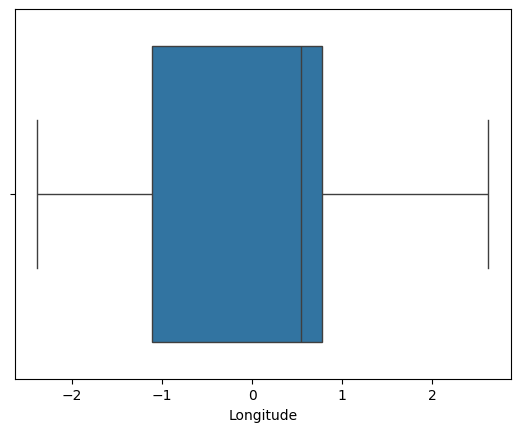

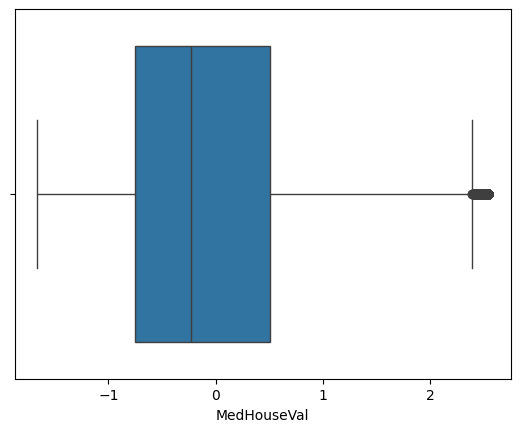

In [22]:
for column in scaled_df:
    plt.figure()
    sns.boxplot(x=scaled_df[column])

In [23]:
a = scaled_df.drop(['MedHouseVal'],axis = 1)

In [24]:
a

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,2.344766,0.982143,0.628559,-0.153758,-0.974429,-0.049597,1.052548,-1.327835
1,2.332238,-0.607019,0.327041,-0.263336,0.861439,-0.092512,1.043185,-1.322844
2,1.782699,1.856182,1.155620,-0.049016,-0.820777,-0.025843,1.038503,-1.332827
3,0.932968,1.856182,0.156966,-0.049833,-0.766028,-0.050329,1.038503,-1.337818
4,-0.012881,1.856182,0.344711,-0.032906,-0.759847,-0.085616,1.038503,-1.337818
...,...,...,...,...,...,...,...,...
20635,-1.216128,-0.289187,-0.155023,0.077354,-0.512592,-0.049110,1.801647,-0.758826
20636,-0.691593,-0.845393,0.276881,0.462365,-0.944405,0.005021,1.806329,-0.818722
20637,-1.142593,-0.924851,-0.090318,0.049414,-0.369537,-0.071735,1.778237,-0.823713
20638,-1.054583,-0.845393,-0.040211,0.158778,-0.604429,-0.091225,1.778237,-0.873626


In [25]:
X=a

In [26]:
Y =scaled_df['MedHouseVal']

In [27]:
Y

0        2.129631
1        1.314156
2        1.258693
3        1.165100
4        1.172900
           ...   
20635   -1.115804
20636   -1.124470
20637   -0.992746
20638   -1.058608
20639   -1.017878
Name: MedHouseVal, Length: 20640, dtype: float64

In [28]:
X.shape

(20640, 8)

In [29]:
Y.shape

(20640,)

In [30]:
#Train test split

from sklearn.model_selection import train_test_split

In [31]:
xtrain,xtest,ytrain,ytest = train_test_split(X,Y,test_size=0.2,random_state=1)

In [32]:
xtest

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
4712,-0.326708,0.823227,-0.374193,-0.048443,-0.279466,-0.124537,-0.735924,0.603801
2151,-0.996050,0.664310,-0.178009,-0.122098,-0.249442,-0.044394,0.537543,-0.104965
15927,0.075024,1.379433,-0.383452,-0.178012,0.095832,0.068138,0.982320,-1.422670
82,-1.236920,1.856182,-0.614747,0.038547,-1.082161,-0.074313,1.019775,-1.352792
8161,0.688939,0.664310,-0.009150,-0.151805,-0.630921,-0.053755,-0.848289,0.718601
...,...,...,...,...,...,...,...,...
2319,-0.817660,-0.289187,-0.207634,0.040151,0.049913,-0.000835,0.556271,-0.065035
5341,-0.885984,1.617807,-0.346618,-0.203999,-1.246409,-0.103088,-0.745288,0.563870
16888,0.619720,-0.209729,-0.173395,-0.203999,-1.249058,0.057387,0.921456,-1.397714
6823,0.528657,1.061601,-0.032745,-0.080327,-0.526721,-0.003276,-0.721879,0.733575


In [33]:
ytest

4712     1.283825
2151    -1.179933
15927    0.195369
82      -0.817692
8161     0.160705
           ...   
2319    -1.201598
5341     0.157238
16888    1.240495
6823     0.177170
11878   -0.564644
Name: MedHouseVal, Length: 4128, dtype: float64

In [34]:
ytrain

15961    0.422420
1771    -0.799494
16414   -0.601041
5056    -0.763096
8589     1.870517
           ...   
10955   -0.013483
17289    2.540411
5192    -0.884421
12172   -0.573310
235     -0.700701
Name: MedHouseVal, Length: 16512, dtype: float64

In [35]:
xtrain

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
15961,-0.357869,1.856182,-0.173395,-0.174068,-0.482568,0.004464,0.972957,-1.427661
1771,-0.137527,1.061601,-0.213414,-0.294534,-0.401327,0.012899,1.085321,-1.387731
16414,-0.655694,-1.004309,1.173889,1.202769,-1.241111,0.025292,1.061912,-0.833696
5056,-1.240342,0.425936,-0.656000,0.111523,1.865470,-0.047185,-0.754652,0.608792
8589,1.823862,0.743768,0.188312,-0.083035,-0.596482,-0.065678,-0.815516,0.588827
...,...,...,...,...,...,...,...,...
10955,-1.099272,-0.924851,-0.555332,-0.020087,-0.305957,-0.057375,-0.876380,0.843383
17289,2.468780,1.061601,0.549474,-0.179651,-0.593833,-0.016802,-0.567377,-0.030095
5192,-1.441260,1.061601,-0.217538,-0.189596,-0.574406,-0.040979,-0.796789,0.653714
12172,-0.651904,-1.481058,-0.176785,-0.305747,-0.090492,-0.028604,-0.890426,1.202758


In [36]:
#Model Creation

linreg = LinearRegression()
linreg.fit(xtrain,ytrain)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [37]:
LinearRegression(copy_X=True,fit_intercept=True,n_jobs=None)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [38]:
y_predict = linreg.predict(xtest)

In [39]:
y_predict

array([ 0.04949951, -0.9782125 ,  0.55489912, ...,  0.76046823,
        0.49413524, -0.51884199], shape=(4128,))

In [40]:
list(y_predict)

[np.float64(0.04949950975014345),
 np.float64(-0.9782124960113798),
 np.float64(0.5548991227492771),
 np.float64(-0.30816607606247165),
 np.float64(0.6571006714452347),
 np.float64(1.2362340586884668),
 np.float64(0.8185074748782046),
 np.float64(-0.37994138804770566),
 np.float64(-0.28285705460288463),
 np.float64(-0.04181293296170389),
 np.float64(0.1858441092910738),
 np.float64(-1.0602946095831804),
 np.float64(-0.6387093974927982),
 np.float64(0.5507168371485646),
 np.float64(-0.7117899965602731),
 np.float64(-0.21243531271600974),
 np.float64(1.519811853534883),
 np.float64(-0.02536671418983271),
 np.float64(-0.49099164648853283),
 np.float64(0.6209469552806905),
 np.float64(-1.7808754476606796),
 np.float64(-0.15605915465398834),
 np.float64(-0.8908639338542916),
 np.float64(0.14699766801934605),
 np.float64(0.7763081533077555),
 np.float64(-0.5692793299777065),
 np.float64(-0.7922723524826716),
 np.float64(0.43344532167554956),
 np.float64(1.7544697960202504),
 np.float64(-0.37

In [41]:
print(sqrt(mean_squared_error(ytest,y_predict)))
print((r2_score(ytest,y_predict)))

0.6303860650696058
0.5965968374812353


In [42]:
from sklearn.ensemble import RandomForestRegressor

rfreg = RandomForestRegressor()

In [43]:
rfreg.fit(xtrain,ytrain)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [44]:
ypredict = rfreg.predict(xtest)

In [45]:
ypredict


array([ 1.30714617, -1.25573512,  0.28480267, ...,  0.44697914,
        0.19499639, -0.77339142], shape=(4128,))

In [46]:
list(ypredict)

[np.float64(1.3071461687376915),
 np.float64(-1.2557351176740794),
 np.float64(0.2848026677568855),
 np.float64(-0.7121397728309524),
 np.float64(0.6878953371023538),
 np.float64(0.9195836683726145),
 np.float64(0.30078295139621436),
 np.float64(-0.4087760117459572),
 np.float64(-0.5836569092691025),
 np.float64(-0.4151195606551219),
 np.float64(1.4446591435001408),
 np.float64(-0.6913239197164539),
 np.float64(-1.1095041828472443),
 np.float64(0.7647201340780532),
 np.float64(-0.9433326659985671),
 np.float64(-0.7961744637765394),
 np.float64(1.7316620080112568),
 np.float64(-0.4296958574655249),
 np.float64(-0.37625232451085516),
 np.float64(0.4305743019113363),
 np.float64(-1.2334547020382025),
 np.float64(-0.6470230699573698),
 np.float64(-1.1664488001725457),
 np.float64(-0.2995664443234267),
 np.float64(0.6461423061674428),
 np.float64(-0.9834738115549198),
 np.float64(-0.9083564864939376),
 np.float64(0.3994025185421217),
 np.float64(1.9951626304374483),
 np.float64(0.2670546831

In [47]:
print(sqrt(mean_squared_error(ytest,ypredict)))
print((r2_score(ytest,ypredict)))

0.43776152757582476
0.8054634219390017


In [48]:
#visualising
scaled_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,2.344766,0.982143,0.628559,-0.153758,-0.974429,-0.049597,1.052548,-1.327835,2.129631
1,2.332238,-0.607019,0.327041,-0.263336,0.861439,-0.092512,1.043185,-1.322844,1.314156
2,1.782699,1.856182,1.155620,-0.049016,-0.820777,-0.025843,1.038503,-1.332827,1.258693
3,0.932968,1.856182,0.156966,-0.049833,-0.766028,-0.050329,1.038503,-1.337818,1.165100
4,-0.012881,1.856182,0.344711,-0.032906,-0.759847,-0.085616,1.038503,-1.337818,1.172900


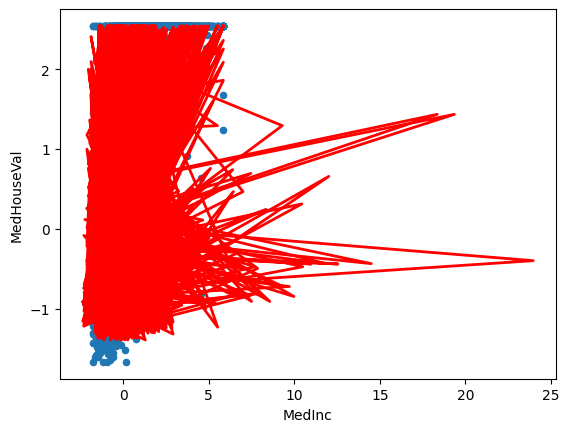

In [49]:
scaled_df.plot(kind = 'scatter', x = 'MedInc',y = 'MedHouseVal')
plt.plot(xtest,ypredict,c = 'red',linewidth = 2)

In [50]:
#Classification

sns.get_dataset_names()

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

In [51]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

In [52]:
df_classification = sns.load_dataset('iris')

In [53]:
df_classification

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [54]:
df_classification.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [55]:
df_classification.shape

(150, 5)

In [56]:
df_classification.info

<bound method DataFrame.info of      sepal_length  sepal_width  petal_length  petal_width    species
0             5.1          3.5           1.4          0.2     setosa
1             4.9          3.0           1.4          0.2     setosa
2             4.7          3.2           1.3          0.2     setosa
3             4.6          3.1           1.5          0.2     setosa
4             5.0          3.6           1.4          0.2     setosa
..            ...          ...           ...          ...        ...
145           6.7          3.0           5.2          2.3  virginica
146           6.3          2.5           5.0          1.9  virginica
147           6.5          3.0           5.2          2.0  virginica
148           6.2          3.4           5.4          2.3  virginica
149           5.9          3.0           5.1          1.8  virginica

[150 rows x 5 columns]>

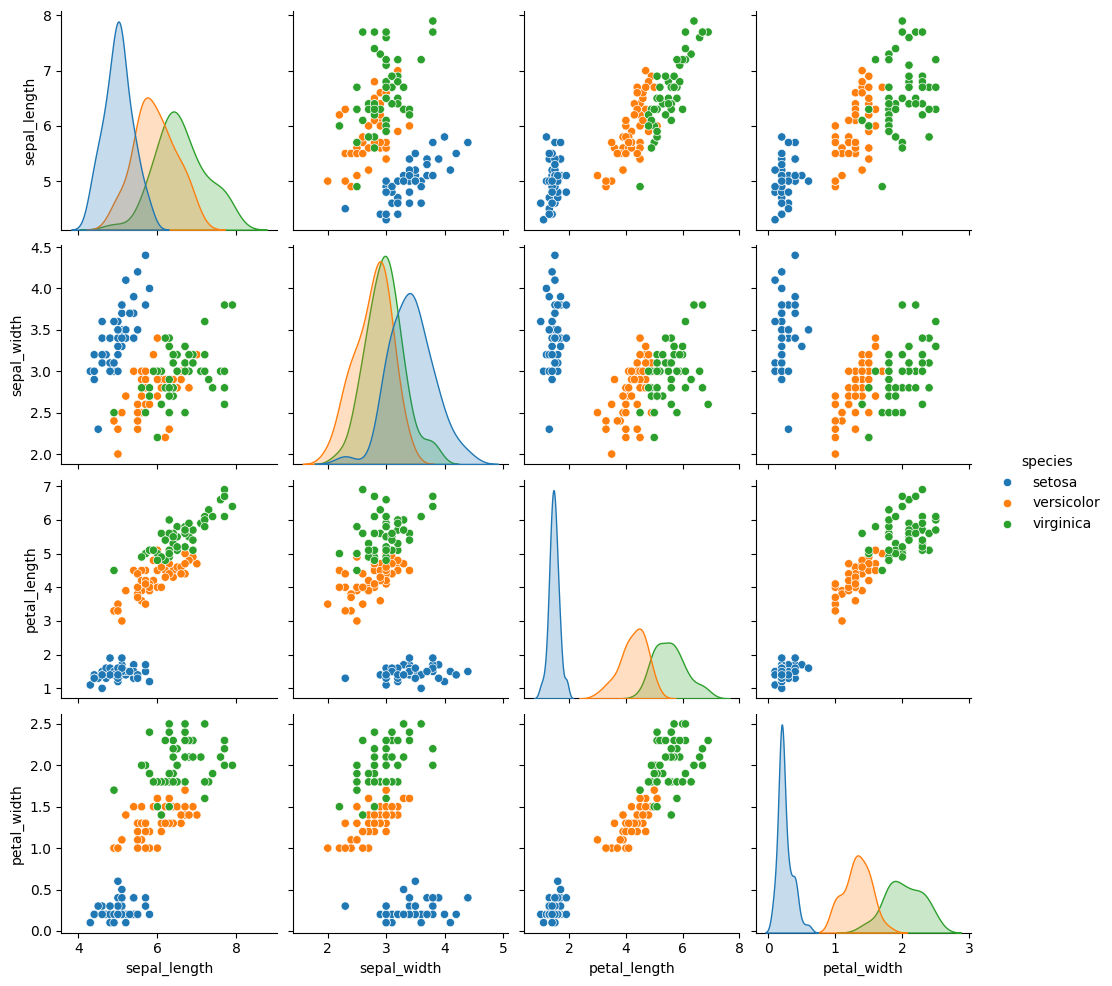

In [57]:
g = sns.pairplot(df_classification,hue = 'species')

In [58]:
le = LabelEncoder()
encodedcl = le.fit_transform(df_classification['species'])

In [59]:
encodedcl

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [60]:
df_classification['species'] = encodedcl

In [61]:
df_classification

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [62]:
classcorr = df_classification.corr()

In [63]:
classcorr

,sepal_length,sepal_width,petal_length,petal_width,species
sepal_length,1.000000,-0.117570,0.871754,0.817941,0.782561
sepal_width,-0.117570,1.000000,-0.428440,-0.366126,-0.426658
petal_length,0.871754,-0.428440,1.000000,0.962865,0.949035
petal_width,0.817941,-0.366126,0.962865,1.000000,0.956547
species,0.782561,-0.426658,0.949035,0.956547,1.000000


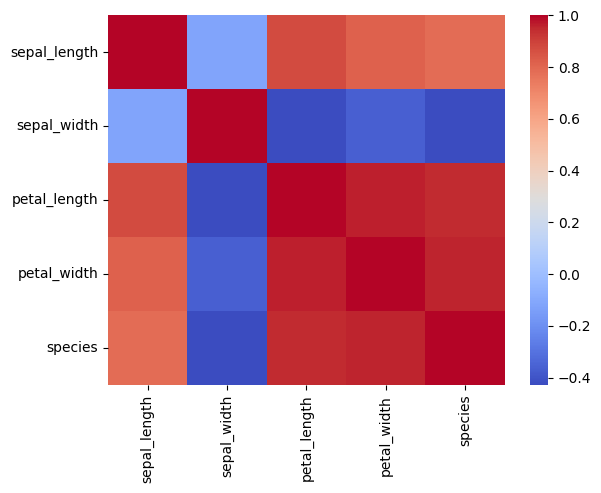

In [64]:
h = sns.heatmap(classcorr,cmap = 'coolwarm')

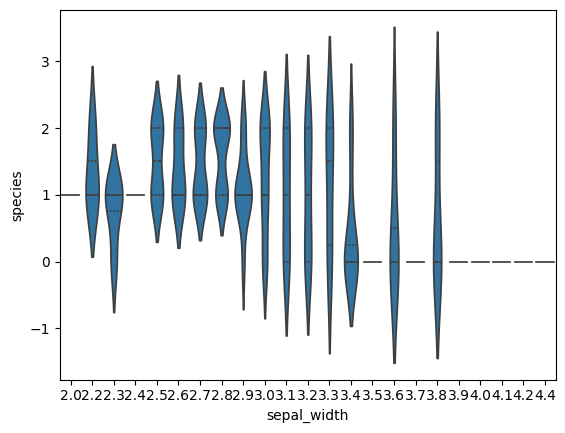

In [65]:
v = sns.violinplot(data = df_classification,y='species',x = 'sepal_width',inner = 'quartile')

In [66]:
dfclass = sns.load_dataset('iris')

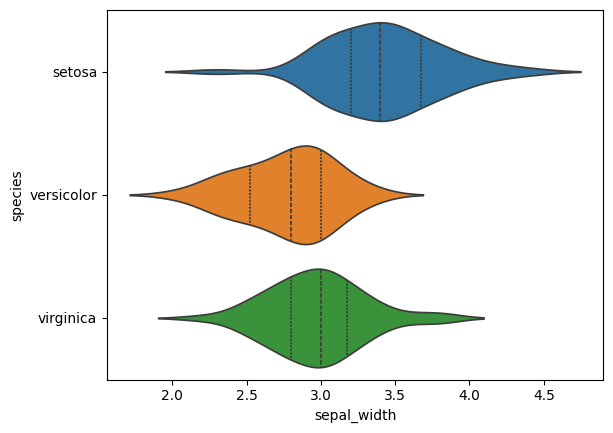

In [67]:
v = sns.violinplot(data = dfclass,y='species',x = 'sepal_width',inner = 'quartile',hue = 'species')

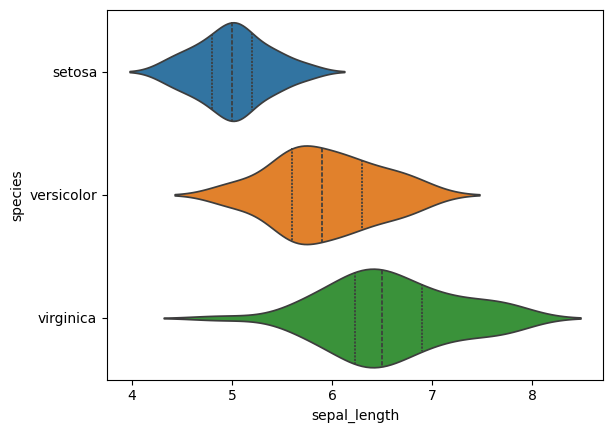

In [68]:
v = sns.violinplot(data = dfclass,y='species',x = 'sepal_length',inner = 'quartile',hue = 'species')

In [69]:
#dimensionality reduction

from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [70]:
iris = dfclass.copy()

In [71]:
iris.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

In [72]:
data = iris[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']].values

In [73]:
target = iris['species'].values

In [74]:
target

array(['setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolo

In [75]:
pca = PCA(n_components=2)
iris['pca1'] = pca.fit(data).transform(data)[:,0]
iris['pca2'] = pca.fit(data).transform(data)[:,1]

In [76]:
iris

,sepal_length,sepal_width,petal_length,petal_width,species,pca1,pca2
0,5.1,3.5,1.4,0.2,setosa,-2.684126,0.319397
1,4.9,3.0,1.4,0.2,setosa,-2.714142,-0.177001
2,4.7,3.2,1.3,0.2,setosa,-2.888991,-0.144949
3,4.6,3.1,1.5,0.2,setosa,-2.745343,-0.318299
4,5.0,3.6,1.4,0.2,setosa,-2.728717,0.326755
...,...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica,1.944110,0.187532
146,6.3,2.5,5.0,1.9,virginica,1.527167,-0.375317
147,6.5,3.0,5.2,2.0,virginica,1.764346,0.078859
148,6.2,3.4,5.4,2.3,virginica,1.900942,0.116628


In [77]:
lda = LinearDiscriminantAnalysis(n_components=2)
iris['lda1'] = lda.fit(data,target).transform(data)[:,0]
iris['lda2'] = lda.fit(data,target).transform(data)[:,1]

In [78]:
iris

,sepal_length,sepal_width,petal_length,petal_width,species,pca1,pca2,lda1,lda2
0,5.1,3.5,1.4,0.2,setosa,-2.684126,0.319397,8.061800,-0.300421
1,4.9,3.0,1.4,0.2,setosa,-2.714142,-0.177001,7.128688,0.786660
2,4.7,3.2,1.3,0.2,setosa,-2.888991,-0.144949,7.489828,0.265384
3,4.6,3.1,1.5,0.2,setosa,-2.745343,-0.318299,6.813201,0.670631
4,5.0,3.6,1.4,0.2,setosa,-2.728717,0.326755,8.132309,-0.514463
...,...,...,...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica,1.944110,0.187532,-5.645003,-1.677717
146,6.3,2.5,5.0,1.9,virginica,1.527167,-0.375317,-5.179565,0.363475
147,6.5,3.0,5.2,2.0,virginica,1.764346,0.078859,-4.967741,-0.821141
148,6.2,3.4,5.4,2.3,virginica,1.900942,0.116628,-5.886145,-2.345091


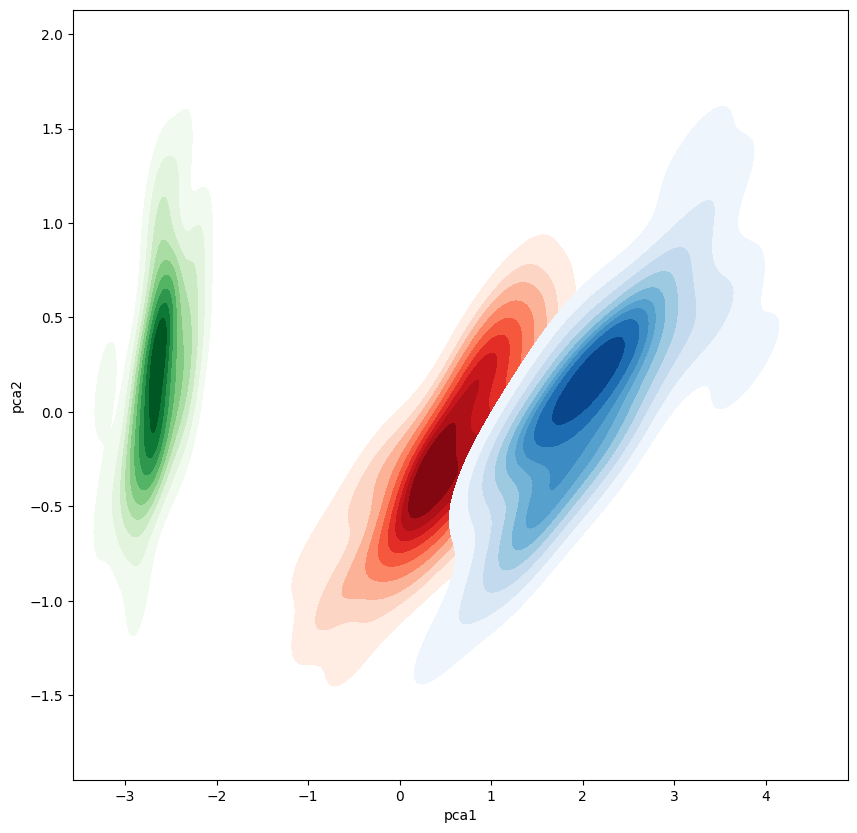

In [79]:
#kdeplot after pca and lda

setosa = iris.query("species =='setosa'")
versicolor =iris.query("species =='versicolor'")
virginica =iris.query("species =='virginica'")
f, ax = plt.subplots(figsize = (10,10))

plt.figure(1)

ax = sns.kdeplot(x=setosa.pca1,y=setosa.pca2,cmap = 'Greens',shade = True,shade_lowest = False)
ax = sns.kdeplot(x=versicolor.pca1,y=versicolor.pca2,cmap = 'Reds',shade = True,shade_lowest = False)
ax = sns.kdeplot(x=virginica.pca1,y=virginica.pca2,cmap = 'Blues',shade = True,shade_lowest = False)

In [80]:
#model selection

In [81]:
iris

,sepal_length,sepal_width,petal_length,petal_width,species,pca1,pca2,lda1,lda2
0,5.1,3.5,1.4,0.2,setosa,-2.684126,0.319397,8.061800,-0.300421
1,4.9,3.0,1.4,0.2,setosa,-2.714142,-0.177001,7.128688,0.786660
2,4.7,3.2,1.3,0.2,setosa,-2.888991,-0.144949,7.489828,0.265384
3,4.6,3.1,1.5,0.2,setosa,-2.745343,-0.318299,6.813201,0.670631
4,5.0,3.6,1.4,0.2,setosa,-2.728717,0.326755,8.132309,-0.514463
...,...,...,...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica,1.944110,0.187532,-5.645003,-1.677717
146,6.3,2.5,5.0,1.9,virginica,1.527167,-0.375317,-5.179565,0.363475
147,6.5,3.0,5.2,2.0,virginica,1.764346,0.078859,-4.967741,-0.821141
148,6.2,3.4,5.4,2.3,virginica,1.900942,0.116628,-5.886145,-2.345091


In [82]:
X = iris.drop(['species'],axis=1)
Y = iris['species'].copy()
print(X.shape)
print(Y.shape)

(150, 8)
(150,)


In [83]:
#data encdoing

Y = le.fit_transform(Y)

In [98]:
Y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [85]:
X_train, X_test, Y_train,Y_test = train_test_split(X,Y,test_size = 0.2,stratify = Y,random_state=5)

In [100]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [86]:
#KNN Classifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix
from sklearn import metrics


In [87]:
k_range = list(range(1,25))

In [103]:
scores_train = []
scores_test = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train,Y_train)
    y_pred_train = knn.predict(X_train)
    y_pred_test = knn.predict(X_test)

    scores_train.append(metrics.accuracy_score(Y_train,y_pred_train))
    scores_test.append(metrics.accuracy_score(Y_test,y_pred_test))
    print(k, np.unique(y_pred_test, return_counts=True))


1 (array([0, 1, 2]), array([10, 11,  9]))
2 (array([0, 1, 2]), array([10, 11,  9]))
3 (array([0, 1, 2]), array([10, 11,  9]))
4 (array([0, 1, 2]), array([10, 11,  9]))
5 (array([0, 1, 2]), array([10, 11,  9]))
6 (array([0, 1, 2]), array([10, 12,  8]))
7 (array([0, 1, 2]), array([10, 11,  9]))
8 (array([0, 1, 2]), array([10, 12,  8]))
9 (array([0, 1, 2]), array([10, 12,  8]))
10 (array([0, 1, 2]), array([10, 12,  8]))
11 (array([0, 1, 2]), array([10, 12,  8]))
12 (array([0, 1, 2]), array([10, 12,  8]))
13 (array([0, 1, 2]), array([10, 12,  8]))
14 (array([0, 1, 2]), array([10, 12,  8]))
15 (array([0, 1, 2]), array([10, 12,  8]))
16 (array([0, 1, 2]), array([10, 12,  8]))
17 (array([0, 1, 2]), array([10, 12,  8]))
18 (array([0, 1, 2]), array([10, 12,  8]))
19 (array([0, 1, 2]), array([10, 11,  9]))
20 (array([0, 1, 2]), array([10, 11,  9]))
21 (array([0, 1, 2]), array([10, 11,  9]))
22 (array([0, 1, 2]), array([10, 11,  9]))
23 (array([0, 1, 2]), array([10, 11,  9]))
24 (array([0, 1, 2])

In [104]:
for k in range(1, 25):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, Y_train)
    print(k, knn.score(X_test, Y_test))

1 0.9666666666666667
2 0.9666666666666667
3 0.9666666666666667
4 0.9666666666666667
5 0.9666666666666667
6 0.9333333333333333
7 0.9666666666666667
8 0.9333333333333333
9 0.9333333333333333
10 0.9333333333333333
11 0.9333333333333333
12 0.9333333333333333
13 0.9333333333333333
14 0.9333333333333333
15 0.9333333333333333
16 0.9333333333333333
17 0.9333333333333333
18 0.9333333333333333
19 0.9666666666666667
20 0.9666666666666667
21 0.9666666666666667
22 0.9666666666666667
23 0.9666666666666667
24 0.9333333333333333


In [89]:
knn

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",24
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [90]:
#plotting

df_plot = pd.DataFrame({'scores_train':scores_train,'scores_test':scores_test})

In [91]:
print('Confusion Matrix')

Confusion Matrix


In [92]:
print(confusion_matrix(Y_train,y_pred_train))
print(confusion_matrix(Y_test,y_pred_test))

[[40  0  0]
 [ 0 39  1]
 [ 0  1 39]]
[[10  0  0]
 [ 0 10  0]
 [ 0  1  9]]


In [105]:
df_plot

,scores_train,scores_test
0,1.000000,0.966667
1,0.991667,0.966667
2,0.983333,0.966667
3,0.966667,0.966667
4,0.966667,0.966667
5,0.975000,0.966667
6,0.983333,0.966667
7,0.983333,0.966667
8,0.983333,0.966667
9,0.991667,0.966667


<Axes: title={'center': 'Accuracy of KNN Classifier model fitting on traain and test sets'}>

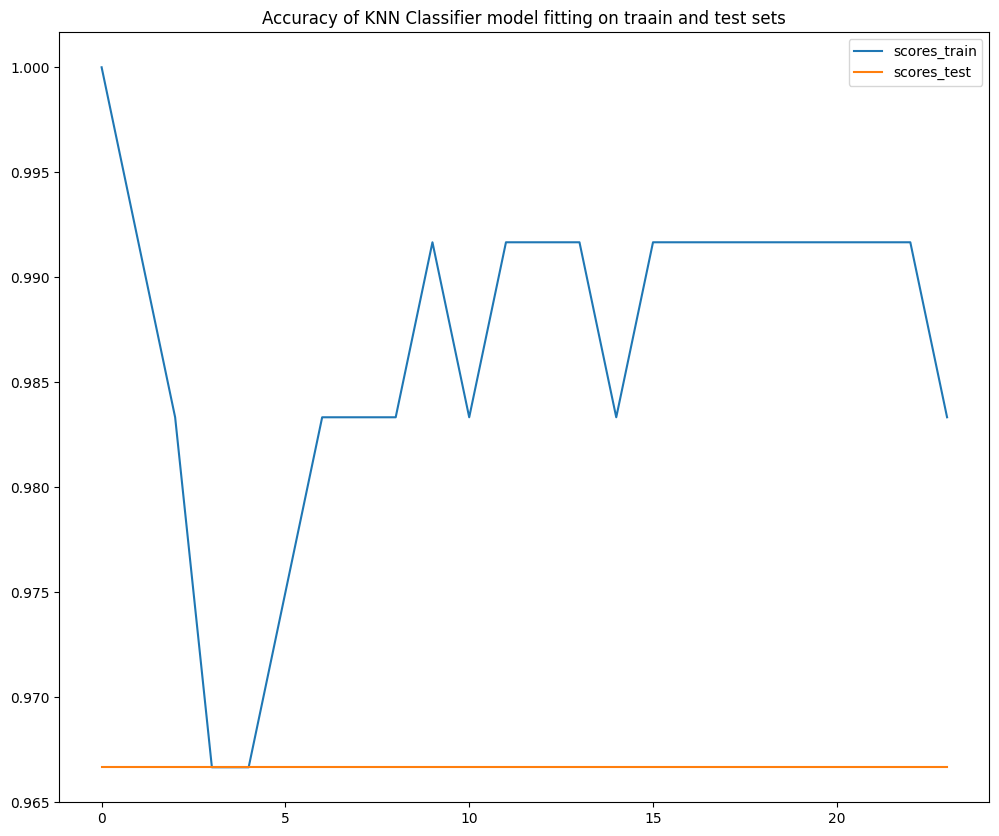

In [102]:
df_plot.plot(figsize = (12,10),title = 'Accuracy of KNN Classifier model fitting on traain and test sets')

In [108]:
#Boosting and Bagging techniques
from xgboost import XGBClassifier

In [115]:
xgb = XGBClassifier()
xgb.fit(X_train, Y_train)
y_pred_train = xgb.predict(X_train)
y_pred_test = xgb.predict(X_test)


In [ ]:
print(metrics.accuracy_score(Y_train,y_pred_train))

1.0


In [117]:
print(metrics.accuracy_score(Y_test,y_pred_test))

0.9666666666666667
